In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dropout, Dense

In [2]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [3]:
X_train = train_df['text']
y_train = train_df['label']

X_test = test_df['text']
y_test = test_df['label']

In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D

model = Sequential([
    Embedding(input_dim=10000, output_dim=16, input_length=100),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [7]:
model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7836 - loss: 0.4949 - val_accuracy: 0.8432 - val_loss: 0.3552
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8782 - loss: 0.2949 - val_accuracy: 0.8512 - val_loss: 0.3335
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9019 - loss: 0.2430 - val_accuracy: 0.8528 - val_loss: 0.3359
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9188 - loss: 0.2103 - val_accuracy: 0.8448 - val_loss: 0.3705
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9301 - loss: 0.1872 - val_accuracy: 0.8426 - val_loss: 0.3868


In [8]:
loss, acc = model.evaluate(X_test_pad, y_test)

print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8426 - loss: 0.3868
Accuracy: 0.8426399827003479


In [9]:
sample = ["I love this movie"]

seq = tokenizer.texts_to_sequences(sample)
pad = pad_sequences(seq, maxlen=100)

prediction = model.predict(pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[[0.62392014]]


In [10]:
if prediction[0][0] > 0.5:
    print("Positive 😊")
else:
    print("Negative 😡")

Positive 😊


In [11]:
samples = [
    "I love this movie",
    "This is the worst film ever",
    "Amazing acting and story",
    "Very boring and bad"
]

for s in samples:
    seq = tokenizer.texts_to_sequences([s])
    pad = pad_sequences(seq, maxlen=100)
    pred = model.predict(pad)[0][0]

    sentiment = "Positive 😊" if pred > 0.5 else "Negative 😡"

    print(s, "=>", sentiment)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
I love this movie => Positive 😊
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
This is the worst film ever => Negative 😡
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Amazing acting and story => Positive 😊
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Very boring and bad => Negative 😡


In [12]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9385 - loss: 0.1696 - val_accuracy: 0.8417 - val_loss: 0.4049
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9456 - loss: 0.1535 - val_accuracy: 0.8359 - val_loss: 0.4461
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9496 - loss: 0.1406 - val_accuracy: 0.8312 - val_loss: 0.4854
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9566 - loss: 0.1262 - val_accuracy: 0.8308 - val_loss: 0.5157
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9612 - loss: 0.1178 - val_accuracy: 0.8268 - val_loss: 0.5507


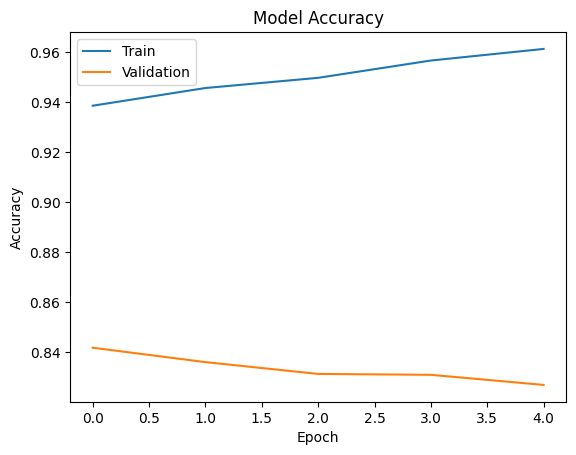

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [14]:
from tensorflow.keras.layers import Bidirectional

model_lstm = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=100),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [15]:
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 326ms/step - accuracy: 0.7666 - loss: 0.4561 - val_accuracy: 0.8505 - val_loss: 0.3409
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 328ms/step - accuracy: 0.8958 - loss: 0.2647 - val_accuracy: 0.8502 - val_loss: 0.3638
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 327ms/step - accuracy: 0.9240 - loss: 0.2041 - val_accuracy: 0.8317 - val_loss: 0.4047
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 329ms/step - accuracy: 0.9455 - loss: 0.1523 - val_accuracy: 0.8360 - val_loss: 0.4851
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 330ms/step - accuracy: 0.9606 - loss: 0.1121 - val_accuracy: 0.8364 - val_loss: 0.5733


In [16]:
loss, acc = model_lstm.evaluate(X_test_pad, y_test)

print("LSTM Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8364 - loss: 0.5733
LSTM Accuracy: 0.8364400267601013


In [17]:
print("Naive Bayes Accuracy: 0.86")
print("LSTM Accuracy:", acc)

Naive Bayes Accuracy: 0.86
LSTM Accuracy: 0.8364400267601013


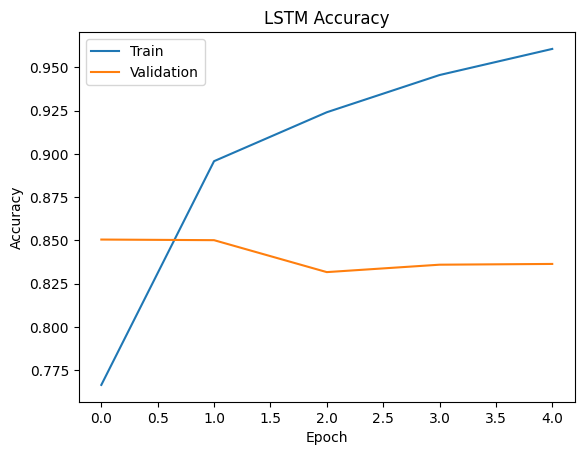

In [18]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()